# BuildSafe — NYC Construction Violation Severity Prediction
## Notebook 2: Data Preprocessing, Feature Engineering & Feature Selection

Input: raw `DOB_ECB_Violations_20260929.csv`  Output: a **fitted, reusable preprocessing pipeline** + model-ready train/test matrices for the modelling stage (≥ 4 algorithms).

Every step below is taken **only because Notebook 1 (EDA) produced evidence for it** – the EDA section that justifies each step is referenced in brackets, e.g. *[EDA §11]*.

**Order of operations (leakage-safe)**
```
Load raw data
  ↓  remove empty / leakage / ID / PII columns            (decided by EDA – no statistics learned from data)
  ↓  clean (duplicates, placeholder codes, text masking)   (row-wise rules only)
  ↓  engineer row-wise + strictly backward-looking features (uses only the past of each row)
  ↓  CHRONOLOGICAL train / test split
  ↓  fit TF-IDF, encoders, scalers, selectors on TRAIN only
  ↓  transform TEST with the fitted pipeline
  ↓  save pipeline + matrices for modelling
```

## 0. Setup

In [5]:
import warnings, re, json, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import sparse

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, VarianceThreshold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report, recall_score

CLASS_ORDER  = ['CLASS - 1', 'CLASS - 2', 'CLASS - 3']
CLASS_COLORS = {'CLASS - 1': '#2a78d6', 'CLASS - 2': '#eb6834', 'CLASS - 3': '#1baf7a'}
NEUTRAL = '#2a78d6'
sns.set_theme(style='whitegrid', rc={'axes.titleweight': 'bold', 'grid.color': '#eeeeee'})
pd.set_option('display.max_colwidth', 120)

DATA_PATH = 'DOB_ECB_Violations_20260913 (1).csv'
OUT_DIR = 'artifacts'; os.makedirs(OUT_DIR, exist_ok=True)
RANDOM_STATE = 42
TARGET = 'SEVERITY'

## 1. Load raw data

In [6]:
raw = pd.read_csv(DATA_PATH, dtype=str, low_memory=False)   # strings: protect codes & leading zeros [EDA §1]
print(raw.shape)
# Guard: keep only valid target labels (EDA found none invalid / "Unknown", but the pipeline must be robust)
valid = raw[TARGET].isin(CLASS_ORDER)
print('Rows with invalid/unknown target removed:', (~valid).sum())
df = raw[valid].copy()

(102467, 46)
Rows with invalid/unknown target removed: 0


## 2. Data Cleaning
### 2.1 Remove duplicate re-entries  *[EDA §4]*
Rows identical in every field except the two system IDs are the same violation entered twice. Removing them **before** the split prevents one copy landing in train and the other in test.

In [7]:
ID_COLS = ['ISN_DOB_BIS_EXTRACT', 'ECB_VIOLATION_NUMBER']
non_id = [c for c in df.columns if c not in ID_COLS]
n0 = len(df)
df = df.drop_duplicates(subset=non_id, keep='first').reset_index(drop=True)
print(f'Duplicates removed: {n0 - len(df)}  ->  {len(df):,} rows')

Duplicates removed: 133  ->  102,334 rows


### 2.2 Drop columns — with the reason for each  *[EDA §3, §11]*
This is a **domain/evidence-based** decision, not learned from data statistics, so it is safe to do before splitting.

In [8]:
DROP = {}
for i in range(4, 11):
    DROP[f'INFRACTION_CODE{i}'] = 'empty (100% missing)'
    DROP[f'SECTION_LAW_DESCRIPTION{i}'] = 'empty (100% missing)'
for i in range(1, 4):
    DROP[f'INFRACTION_CODE{i}'] = 'LEAKAGE – code legally defines the class (1-feature tree ≈ 98% acc.)'
    DROP[f'SECTION_LAW_DESCRIPTION{i}'] = 'LEAKAGE – text version of the infraction code'
DROP.update({
 'PENALITY_IMPOSED':     'LEAKAGE – penalty schedule set by class; imposed at hearing',
 'AMOUNT_PAID':          'LEAKAGE / post-event – exists only after payment',
 'BALANCE_DUE':          'LEAKAGE / post-event – penalty minus payment',
 'HEARING_STATUS':       'post-event – hearing outcome (CURED/IN-VIO never Class 1)',
 'CERTIFICATION_STATUS': 'post-event – CURE ACCEPTED never Class 1',
 'ECB_VIOLATION_STATUS': 'post-event – current ACTIVE/RESOLVE status',
 'HEARING_DATE':         'post-event – rescheduled after adjournments',
 'HEARING_TIME':         'operational scheduling slot, no causal meaning',
 'SERVED_DATE':          'weak signal (lag = 0 for >75%), not always known at triage',
 'ISN_DOB_BIS_EXTRACT':  'identifier (unique per row)',
 'ECB_VIOLATION_NUMBER': 'identifier (unique per row)',
 'BLOCK':                'location identifier (10k levels); BORO + BIN history cover location',
 'LOT':                  'location identifier',
 'RESPONDENT_HOUSE_NUMBER': 'PII – respondent mailing address',
 'RESPONDENT_STREET':    'PII – respondent mailing address',
 'RESPONDENT_CITY':      'PII – mailing city, not the building location',
 'RESPONDENT_ZIP':       'PII – mailing ZIP, not the building location',
})
# Kept *temporarily* for feature engineering, dropped later: BIN, ISSUE_DATE, RESPONDENT_NAME, DOB_VIOLATION_NUMBER
drop_tbl = pd.DataFrame({'column': DROP.keys(), 'reason': DROP.values()})
display(drop_tbl)
df = df.drop(columns=list(DROP))
print('Remaining columns:', list(df.columns))

,column,reason
0,INFRACTION_CODE4,empty (100% missing)
1,SECTION_LAW_DESCRIPTION4,empty (100% missing)
2,INFRACTION_CODE5,empty (100% missing)
3,SECTION_LAW_DESCRIPTION5,empty (100% missing)
4,INFRACTION_CODE6,empty (100% missing)
5,SECTION_LAW_DESCRIPTION6,empty (100% missing)
6,INFRACTION_CODE7,empty (100% missing)
7,SECTION_LAW_DESCRIPTION7,empty (100% missing)
8,INFRACTION_CODE8,empty (100% missing)
9,SECTION_LAW_DESCRIPTION8,empty (100% missing)


Remaining columns: ['DOB_VIOLATION_NUMBER', 'BIN', 'BORO', 'ISSUE_DATE', 'SEVERITY', 'VIOLATION_TYPE', 'RESPONDENT_NAME', 'VIOLATION_DESCRIPTION', 'AGGRAVATED_LEVEL']


### 2.3 Fix invalid values & handle missing values — column by column  *[EDA §3, §4]*

| Column | Problem | Action | Why |
|---|---|---|---|
| BIN | placeholder `x000000` (95 rows), 0.11 % missing | → NaN | a fake "building" would get a huge fake history |
| VIOLATION_DESCRIPTION | 18 missing | → `''` | row is otherwise valid; empty TF-IDF vector |
| RESPONDENT_NAME | 112 missing | → `''` → type `UNKNOWN` | tiny share; own category |
| DOB_VIOLATION_NUMBER | 75.6 % missing, **informative** | → flag + `NONE` unit | missing-not-at-random |
| VIOLATION_TYPE = 'Unknown' | a real source category | keep as a level | not a missing value |

No mean/median imputation is applied — no remaining numeric column has missing values.

In [9]:
df['BIN'] = df['BIN'].where(~df['BIN'].str.fullmatch(r'[1-5]000000', na=False))
df['VIOLATION_DESCRIPTION'] = df['VIOLATION_DESCRIPTION'].fillna('')
df['RESPONDENT_NAME'] = df['RESPONDENT_NAME'].fillna('')
df['ISSUE_DATE'] = pd.to_datetime(df['ISSUE_DATE'], format='%Y%m%d', errors='raise')
print(df.isna().sum()[df.isna().sum() > 0])

DOB_VIOLATION_NUMBER    80682
BIN                       176
dtype: int64


### 2.4 Text cleaning & leakage masking  *[EDA §7]*
Rules (row-wise, no learning → safe before split):
1. **Mask explicit class vocabulary** (`CLASS 1/2/3`, `IMMEDIATELY HAZARDOUS`, `MAJOR`, `LESSER`) – direct leakage words.
2. Replace **URLs** → `URL`, **dates & month names** → `DATE` (template artefacts, e.g. *AUGUST* was 99 % Class 1).
3. Replace **permit / job / device numbers** → `IDNUM` (identifiers would be memorised).
4. Keep **legal section references** like `28-105.1` / `BC 3307` – written by the inspector at issuance (legitimate content).
5. Upper-case and collapse whitespace. We do **not** stem/lemmatise: the text is technical jargon with fixed phrasing, and TF-IDF bigrams already capture it.

In [10]:
MONTHS = r'\b(JAN|JANUARY|FEB|FEBRUARY|MARCH|APRIL|JUNE|JULY|AUG|AUGUST|SEPT|SEPTEMBER|OCT|OCTOBER|NOV|NOVEMBER|DEC|DECEMBER)\b'

def clean_description(s: str) -> str:
    s = str(s).upper()
    s = re.sub(r'HTTPS?://\S+|WWW\.\S+', ' URL ', s)
    CLS = r'CLASS\s*[-#:.]?\s*[123](?![0-9])'
    s = re.sub(CLS, ' ', s)                                        # leakage masking
    s = re.sub(r'\bIMMEDIATELY\s+HAZARDOUS\b', ' ', s)
    s = re.sub(r'\b(MAJOR|LESSER)\b', ' ', s)
    s = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', ' DATE ', s)
    s = re.sub(MONTHS, ' DATE ', s)
    s = re.sub(r'\b[A-Z]{0,3}\d{6,}[A-Z0-9-]*\b', ' IDNUM ', s)    # permit / job / device numbers
    s = re.sub(r'[^A-Z0-9\.\-/ ]', ' ', s)
    s = re.sub(CLS, ' ', s)                                        # again: punctuation removal can create new matches
    return re.sub(r'\s+', ' ', s).strip()

df['DESC_CLEAN'] = df['VIOLATION_DESCRIPTION'].map(clean_description)
ex = df.loc[df['VIOLATION_DESCRIPTION'].str.contains(r'CLASS\s*[12]|/20|HTTP', regex=True),
            ['VIOLATION_DESCRIPTION', 'DESC_CLEAN']].head(5)
display(ex)
left = df['DESC_CLEAN'].str.contains(r'CLASS\s*[-#:.]?\s*[123](?![0-9])')
print('Rows still containing "CLASS n" after masking:', left.sum())
print(df.loc[left, 'DESC_CLEAN'].head(3).to_string())

,VIOLATION_DESCRIPTION,DESC_CLEAN
0,"AS PER PREVIOUS REQUEST FOR CORRECTIVE ACTION ISSUED ON 11/28/2025 BY BADGE # 3734, ILLEGAL USE IN RESIDENTIAL DISTR...",AS PER PREVIOUS REQUEST FOR CORRECTIVE ACTION ISSUED ON DATE BY BADGE 3734 ILLEGAL USE IN RESIDENTIAL DISTRICT 2ND F...
1,TEMP CONSTRUCTION EQUIP/INSTALLATION ON SITE EXPIRED PERMIT(SHED). AT TIME OF INSPECTION INSTALLED SIDEWALK SHED PER...,TEMP CONSTRUCTION EQUIP/INSTALLATION ON SITE EXPIRED PERMIT SHED . AT TIME OF INSPECTION INSTALLED SIDEWALK SHED PER...
2,"UNLAWFUL ACTS. FAILURE TO COMPLY WITH COMMISSIONER'S ORDER. FOR WORK WITHOUT A PERMIT FOR VIO#39162126K ,NO PERMIT O...",UNLAWFUL ACTS. FAILURE TO COMPLY WITH COMMISSIONER S ORDER. FOR WORK WITHOUT A PERMIT FOR VIO IDNUM NO PERMIT ON FIL...
8,UNLAWFUL ACTS. FAILURE TO COMPLY WITH COMMISSIONER'S ORDER. FOR WORK WITHOUT A PERMIT FOR VIO#39169743H. NO PERMIT O...,UNLAWFUL ACTS. FAILURE TO COMPLY WITH COMMISSIONER S ORDER. FOR WORK WITHOUT A PERMIT FOR VIO IDNUM . NO PERMIT ON F...
9,FAILURE TO COMPLY WITH THE COMMISSIONER'S ORDER TO FILE A CERTIFICATE OF CORRECTION WITH THE DEPARTMENT OF BUILDINGS...,FAILURE TO COMPLY WITH THE COMMISSIONER S ORDER TO FILE A CERTIFICATE OF CORRECTION WITH THE DEPARTMENT OF BUILDINGS...


Rows still containing "CLASS n" after masking: 0
Series([], )


## 3. Feature Engineering
All features here are either **row-wise** (use only the row itself) or **strictly backward-looking** (use only violations issued on *earlier dates*). Therefore they can be computed before the split without leaking test information into training — and they can be reproduced identically at prediction time.

| New feature | Built from | Why it helps *[EDA evidence]* |
|---|---|---|
| `ISSUE_MONTH`, `ISSUE_DAYOFWEEK`, `IS_WEEKEND` | ISSUE_DATE | Weekend ⇒ Class 1 ≈ 45–52 % vs 39 % (emergency inspections); mild month effect [§8]. Year excluded (drift). |
| `RESPONDENT_TYPE` | RESPONDENT_NAME | Government 91 % Class 2, Individual 8.8 % Class 3; replaces PII name & fixes spelling variants [§4, §10] |
| `HAS_DOB_VIOLATION`, `DOB_UNIT` | DOB_VIOLATION_NUMBER | Informative missingness; issuing unit is 2nd-strongest context signal (V ≈ 0.25) [§3, §10] |
| `AGGRAVATED_ORD` | AGGRAVATED_LEVEL | ordinal 0/1/2 (repeat-offender level) [§6] |
| `BIN_PRIOR_VIOLATIONS` | BIN + date | repeat buildings: more history ⇒ less Class 3 [§9, §10] |
| `BIN_PRIOR_CLASS1` | BIN + date + past labels | a building's past hazardous record (past labels are known at prediction time) |
| `BIN_DAYS_SINCE_PREV`, `BIN_HAS_HISTORY` | BIN + date | recency of enforcement at the site |
| `DESC_WORDS` | description | weak length signal; one of chars/words kept [§10] |
| `DESC_CLEAN` → TF-IDF | description | main signal [§7] |

In [11]:
# --- Date features
df['ISSUE_MONTH'] = df['ISSUE_DATE'].dt.month
df['ISSUE_DAYOFWEEK'] = df['ISSUE_DATE'].dt.dayofweek
df['IS_WEEKEND'] = (df['ISSUE_DAYOFWEEK'] >= 5).astype(int)

# --- Respondent type (domain rule-based normalisation of a PII field)
GOV = r'DEPARTMENT|DEPT|\bNYC\b|CITY OF|HOUSING AUTH|SCHOOL|BOARD OF ED|\bHPD\b|\bDOE\b|AUTHORITY|\bMTA\b|STATE OF'
ORG = (r'\bLLC\b|\bINC\b|CORP|\bCO\b|LTD|\bLP\b|ASSOC|REALTY|MGMT|MANAGEMENT|TRUST|CONDO|CONSTRUCT|DEVELOP|PROPERT|'
       r'HOLDING|GROUP|BUILDERS|CONTRACT|SERVICES|ENTERPRISE|OWNER|CHURCH|HOSPITAL|UNIVERSITY|COOP|CO-OP|HDFC|L\.L\.C')
def respondent_type(name: str) -> str:
    n = str(name).upper().strip()
    if not n: return 'UNKNOWN'
    if re.search(GOV, n): return 'GOVERNMENT'
    if re.search(ORG, n): return 'ORGANISATION'
    return 'INDIVIDUAL'
df['RESPONDENT_TYPE'] = df['RESPONDENT_NAME'].map(respondent_type)

# --- DOB violation number: informative missingness + issuing unit code
df['HAS_DOB_VIOLATION'] = df['DOB_VIOLATION_NUMBER'].notna().astype(int)
df['DOB_UNIT'] = df['DOB_VIOLATION_NUMBER'].str.extract(r'^\d{8}([A-Z]+)')[0].str[:4].fillna('NONE')

# --- Ordinal aggravation level
df['AGGRAVATED_ORD'] = df['AGGRAVATED_LEVEL'].map({'NO': 0, 'AGGRAVATED OFFENSE LEVEL 1': 1,
                                                    'AGGRAVATED OFFENSE LEVEL 2': 2}).fillna(0).astype(int)
# --- Text length
df['DESC_WORDS'] = df['DESC_CLEAN'].str.split().str.len()
df[['ISSUE_MONTH', 'IS_WEEKEND', 'RESPONDENT_TYPE', 'HAS_DOB_VIOLATION', 'DOB_UNIT', 'AGGRAVATED_ORD', 'DESC_WORDS']].head()

,ISSUE_MONTH,IS_WEEKEND,RESPONDENT_TYPE,HAS_DOB_VIOLATION,DOB_UNIT,AGGRAVATED_ORD,DESC_WORDS
0,6,0,INDIVIDUAL,0,NONE,0,34
1,8,0,INDIVIDUAL,0,NONE,0,30
2,6,0,INDIVIDUAL,0,NONE,0,30
3,12,0,INDIVIDUAL,0,NONE,0,36
4,7,0,ORGANISATION,1,SR,0,25


### 3.1 Backward-looking building history (the leakage-sensitive one)
For each violation, count only violations at the same BIN issued on **strictly earlier dates**. Violations on the *same* day are excluded (they come from the same inspection and their classes are not yet "history").
`BIN_PRIOR_CLASS1` uses past *labels* – legitimate because when a new violation is being triaged, the classes of the building's earlier violations are already known.
**Limitation (report):** the extract starts in Jan-2024, so history is left-censored – early-2024 rows look "new" even if the building had older violations.

In [12]:
def add_bin_history(frame: pd.DataFrame) -> pd.DataFrame:
    f = frame[['BIN', 'ISSUE_DATE', TARGET]].copy()
    f['is_c1'] = (f[TARGET] == 'CLASS - 1').astype(int)
    day = (f.dropna(subset=['BIN']).groupby(['BIN', 'ISSUE_DATE'])
             .agg(n=('is_c1', 'size'), c1=('is_c1', 'sum')).reset_index()
             .sort_values(['BIN', 'ISSUE_DATE']))
    g = day.groupby('BIN')
    day['BIN_PRIOR_VIOLATIONS'] = g['n'].cumsum() - day['n']          # strictly earlier dates
    day['BIN_PRIOR_CLASS1']     = g['c1'].cumsum() - day['c1']
    day['BIN_DAYS_SINCE_PREV']  = g['ISSUE_DATE'].diff().dt.days      # gap to previous inspection date
    out = frame.merge(day[['BIN', 'ISSUE_DATE', 'BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV']],
                      on=['BIN', 'ISSUE_DATE'], how='left')
    out['BIN_PRIOR_VIOLATIONS'] = out['BIN_PRIOR_VIOLATIONS'].fillna(0)
    out['BIN_PRIOR_CLASS1'] = out['BIN_PRIOR_CLASS1'].fillna(0)
    out['BIN_HAS_HISTORY'] = (out['BIN_PRIOR_VIOLATIONS'] > 0).astype(int)
    # no previous violation -> gap is undefined; cap at the observation window (1,000 days) and let the flag carry it
    out['BIN_DAYS_SINCE_PREV'] = out['BIN_DAYS_SINCE_PREV'].fillna(1000).clip(upper=1000)
    return out

df = add_bin_history(df)
# sanity check: a row's history must never include itself or later rows
chk = df[df.BIN.notna()].sort_values('ISSUE_DATE').groupby('BIN').head(1)
print('First-ever violation of each BIN has prior count 0:', (chk['BIN_PRIOR_VIOLATIONS'] == 0).all())
df[['BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV', 'BIN_HAS_HISTORY']].describe().round(2)

First-ever violation of each BIN has prior count 0: True


,BIN_PRIOR_VIOLATIONS,BIN_PRIOR_CLASS1,BIN_DAYS_SINCE_PREV,BIN_HAS_HISTORY
count,102334.00,102334.00,102334.00,102334.00
mean,1.65,0.74,657.56,0.40
std,3.46,1.97,430.91,0.49
min,0.00,0.00,1.00,0.00
25%,0.00,0.00,140.00,0.00
50%,0.00,0.00,1000.00,0.00
75%,2.00,0.00,1000.00,1.00
max,60.00,32.00,1000.00,1.00


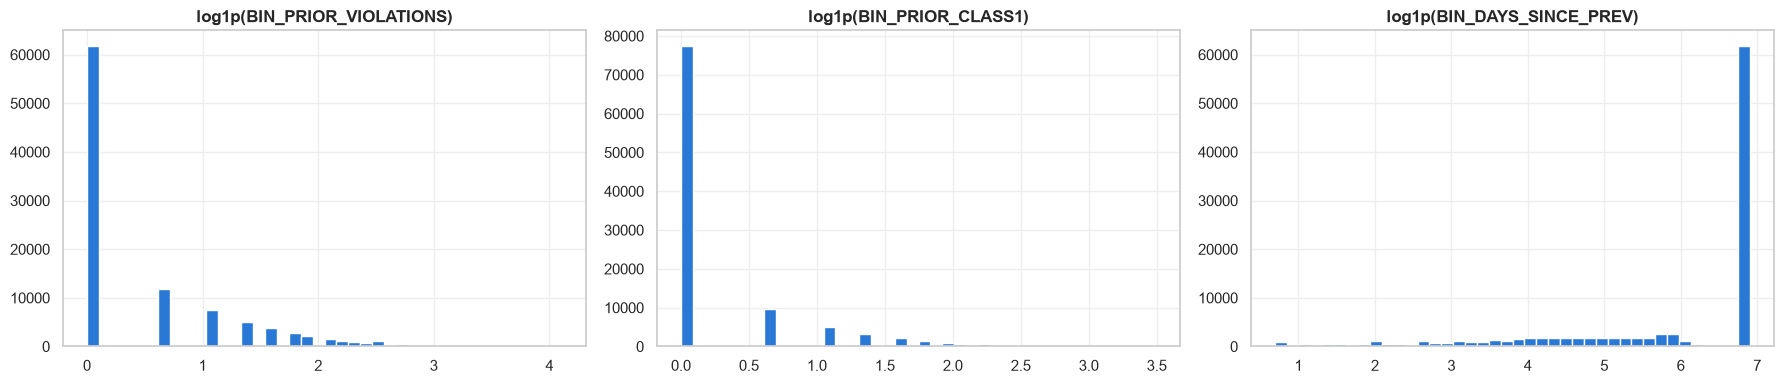

Skewness raw  : {'BIN_PRIOR_VIOLATIONS': 3.92, 'BIN_PRIOR_CLASS1': 4.56}
Skewness log1p: {'BIN_PRIOR_VIOLATIONS': 1.26, 'BIN_PRIOR_CLASS1': 2.03}


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, c in zip(axes, ['BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV']):
    ax.hist(np.log1p(df[c]), bins=40, color=NEUTRAL); ax.set_title(f'log1p({c})')
plt.tight_layout(); plt.show()
print('Skewness raw  :', df[['BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1']].skew().round(2).to_dict())
print('Skewness log1p:', np.log1p(df[['BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1']]).skew().round(2).to_dict())

### 3.2 Final modelling table
Temporary helper columns (BIN, raw name, raw DOB number, raw description, raw aggravated text) are now dropped – they were only needed to build features. `ISSUE_DATE` is kept only to perform the split.

In [14]:
TEXT_COL = 'DESC_CLEAN'
CAT_COLS = ['BORO', 'VIOLATION_TYPE', 'RESPONDENT_TYPE', 'DOB_UNIT', 'ISSUE_MONTH', 'ISSUE_DAYOFWEEK']
BIN_COLS = ['IS_WEEKEND', 'HAS_DOB_VIOLATION', 'BIN_HAS_HISTORY']
NUM_COLS = ['AGGRAVATED_ORD', 'BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV', 'DESC_WORDS']
FEATURES = [TEXT_COL] + CAT_COLS + BIN_COLS + NUM_COLS

model_df = df[FEATURES + ['ISSUE_DATE', TARGET]].copy()
model_df[CAT_COLS] = model_df[CAT_COLS].astype(str)
print(model_df.shape); model_df.head()

(102334, 17)


,DESC_CLEAN,BORO,VIOLATION_TYPE,RESPONDENT_TYPE,DOB_UNIT,ISSUE_MONTH,ISSUE_DAYOFWEEK,IS_WEEKEND,HAS_DOB_VIOLATION,BIN_HAS_HISTORY,AGGRAVATED_ORD,BIN_PRIOR_VIOLATIONS,BIN_PRIOR_CLASS1,BIN_DAYS_SINCE_PREV,DESC_WORDS,ISSUE_DATE,SEVERITY
0,AS PER PREVIOUS REQUEST FOR CORRECTIVE ACTION ISSUED ON DATE BY BADGE 3734 ILLEGAL USE IN RESIDENTIAL DISTRICT 2ND F...,2,Construction,INDIVIDUAL,NONE,6,0,0,0,0,0,0.0,0.0,1000.0,34,2026-06-01,CLASS - 2
1,TEMP CONSTRUCTION EQUIP/INSTALLATION ON SITE EXPIRED PERMIT SHED . AT TIME OF INSPECTION INSTALLED SIDEWALK SHED PER...,1,Unknown,INDIVIDUAL,NONE,8,1,0,0,0,0,0.0,0.0,1000.0,30,2025-08-05,CLASS - 2
2,UNLAWFUL ACTS. FAILURE TO COMPLY WITH COMMISSIONER S ORDER. FOR WORK WITHOUT A PERMIT FOR VIO IDNUM NO PERMIT ON FIL...,5,Construction,INDIVIDUAL,NONE,6,2,0,0,1,0,6.0,6.0,85.0,30,2026-06-24,CLASS - 1
3,WORK WITHOUT A PERMIT. NOTED OBSERVED WORK HAS BEEN DONE TO FULLY ENCLOSE THE GARAGE AT FRONT OF THIS LOCATION ERECT...,4,Construction,INDIVIDUAL,NONE,12,2,0,0,0,0,0.0,0.0,1000.0,36,2025-12-03,CLASS - 2
4,FAILURE TO PROVIDE UNOBSTRUCTED EXIT PASSAGEWAY. OBSERVED THE FOLLOWING OBJECTS STORED AT EXPOSURE 3 NORTH ELEVATION...,2,Construction,ORGANISATION,SR,7,2,0,1,0,0,0.0,0.0,1000.0,25,2026-07-22,CLASS - 1


## 4. Train / Test Split — chronological  *[EDA §8]*
**Why time-based instead of random?**
1. The deployed system always predicts **future** violations.
2. History features look backwards; a random split would put a building's *later* violations in train and *earlier* ones in test.
3. The class mix drifts slightly over time – a time split measures robustness to that drift honestly.

Train = first ~80 % of the timeline, Test = last ~20 % (≈ Mar-2026 → Sep-2026). The test set is **locked** until final model evaluation; model selection uses a time-ordered **validation** slice of train (or `TimeSeriesSplit` CV).

In [15]:
model_df = model_df.sort_values('ISSUE_DATE', kind='mergesort').reset_index(drop=True)
cutoff = model_df['ISSUE_DATE'].quantile(0.80)
train_df = model_df[model_df.ISSUE_DATE < cutoff].copy()
test_df  = model_df[model_df.ISSUE_DATE >= cutoff].copy()
print(f'Cutoff date: {cutoff.date()}')
print(f'Train: {len(train_df):,} rows  {train_df.ISSUE_DATE.min().date()} → {train_df.ISSUE_DATE.max().date()}')
print(f'Test : {len(test_df):,} rows  {test_df.ISSUE_DATE.min().date()} → {test_df.ISSUE_DATE.max().date()}')
dist = pd.DataFrame({'train_%': train_df[TARGET].value_counts(normalize=True)*100,
                     'test_%':  test_df[TARGET].value_counts(normalize=True)*100}).reindex(CLASS_ORDER).round(2)
print(dist)

y_train, y_test = train_df[TARGET], test_df[TARGET]

# time-ordered validation slice inside TRAIN (last 20% of train) for preprocessing/feature-selection decisions
vcut = train_df['ISSUE_DATE'].quantile(0.80)
sub_tr, sub_va = train_df[train_df.ISSUE_DATE < vcut], train_df[train_df.ISSUE_DATE >= vcut]
print(f'\nInner split for decisions: sub-train {len(sub_tr):,} | validation {len(sub_va):,} (from {vcut.date()})')

Cutoff date: 2026-05-13
Train: 81,780 rows  2025-01-01 → 2026-05-12
Test : 20,554 rows  2026-05-13 → 2026-09-10
           train_%  test_%
SEVERITY                  
CLASS - 1    39.30   41.14
CLASS - 2    56.58   54.89
CLASS - 3     4.12    3.97

Inner split for decisions: sub-train 65,211 | validation 16,569 (from 2026-02-18)


The class proportions of train and test are close, so the time split does **not** create an artificial imbalance shift; stratification is unnecessary (and would break time order).

## 5. Encoding, Scaling & Text Vectorisation — one `ColumnTransformer`
| Feature group | Transformer | Justification |
|---|---|---|
| `DESC_CLEAN` | **TF-IDF**, word 1–2-grams, `min_df=5`, `max_df=0.9`, `sublinear_tf=True`, `max_features=40,000` | sparse, fast, interpretable; `min_df` removes typos/IDs, `max_df` removes template words, sublinear dampens repeated words [EDA §7] |
| BORO, VIOLATION_TYPE, RESPONDENT_TYPE, DOB_UNIT, ISSUE_MONTH, ISSUE_DAYOFWEEK | **One-Hot**, `min_frequency=50`, `handle_unknown='infrequent_if_exist'` | nominal, low cardinality (≤ ~40 levels) → no false order (why *not* Label Encoding); rare levels (e.g. *Public Assembly*, 19 rows) merged into "infrequent" to avoid overfitting; unseen levels at prediction time don't crash the system |
| IS_WEEKEND, HAS_DOB_VIOLATION, BIN_HAS_HISTORY | passthrough | already 0/1 |
| AGGRAVATED_ORD, BIN_PRIOR_*, BIN_DAYS_SINCE_PREV, DESC_WORDS | **log1p → MinMaxScaler(clip=True)** | right-skewed counts (skew ≈ 6 → ≈ 1.5 after log); [0,1] range matches TF-IDF & one-hot; **non-negative** as required by chi² selection and Naive Bayes; `clip` bounds unseen extreme values |

**Why not Target Encoding?** No high-cardinality categorical remains (raw BIN/name dropped); target encoding would add leakage risk for no gain.
**Why not Frequency Encoding?** Frequencies of VIOLATION_TYPE/DOB_UNIT would conflate different units with similar volumes – one-hot keeps their identity at negligible cost.

**Scaling vs algorithm**
| Model (planned) | Needs scaling? | Reason |
|---|---|---|
| Logistic Regression / Linear SVM | **Yes** | gradient-based, L2 penalty assumes comparable feature scales |
| Multinomial / Complement Naive Bayes | needs **non-negative** counts/weights | MinMax keeps ≥ 0 (StandardScaler would break NB) |
| Decision Tree / Random Forest / Gradient Boosting (XGBoost/LightGBM) | **No** | split thresholds are invariant to monotonic scaling – the MinMax step is harmless, so one shared pipeline serves all models |

In [16]:
log_minmax = Pipeline([('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
                       ('scale', MinMaxScaler(clip=True))])

def make_preprocessor(max_features=40000, bin_cols=BIN_COLS, num_cols=NUM_COLS):
    return ColumnTransformer([
        ('text', TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.9, sublinear_tf=True,
                                 max_features=max_features, lowercase=False,
                                 token_pattern=r'(?u)\b[A-Z]{2,}\b|\b\d+-\d+(?:\.\d+)*\b'), TEXT_COL),
        ('cat',  OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=50, sparse_output=True), CAT_COLS),
        ('bin',  'passthrough', bin_cols),
        ('num',  log_minmax, num_cols),
    ], sparse_threshold=1.0, verbose_feature_names_out=True)

pre_probe = make_preprocessor().fit(sub_tr[FEATURES])           # fitted on SUB-TRAIN only
Xs_tr, Xs_va = pre_probe.transform(sub_tr[FEATURES]), pre_probe.transform(sub_va[FEATURES])
names_probe = pre_probe.get_feature_names_out()
blocks = pd.Series([n.split('__')[0] for n in names_probe]).value_counts()
print('Matrix shape (sub-train):', Xs_tr.shape, '| density: %.4f%%' % (Xs_tr.nnz / np.prod(Xs_tr.shape) * 100))
print(blocks)
print('One-hot categories kept (rare merged):')
for c, cats in zip(CAT_COLS, pre_probe.named_transformers_['cat'].categories_):
    inf = pre_probe.named_transformers_['cat'].infrequent_categories_[CAT_COLS.index(c)]
    print(f'  {c:16s} {len(cats):3d} levels, infrequent merged: {list(inf) if inf is not None else []}')

Matrix shape (sub-train): (65211, 39779) | density: 0.1411%
text    39709
cat        62
num         5
bin         3
Name: count, dtype: int64
One-hot categories kept (rare merged):
  BORO               5 levels, infrequent merged: []
  VIOLATION_TYPE    12 levels, infrequent merged: ['Public Assembly']
  RESPONDENT_TYPE    4 levels, infrequent merged: ['UNKNOWN']
  DOB_UNIT         132 levels, infrequent merged: ['AERT', 'AHRT', 'AHVG', 'AHVJ', 'AMTF', 'ARZ', 'ASPO', 'BDOE', 'CADG', 'CAHG', 'CAHJ', 'CAHL', 'CAHV', 'CCER', 'CCFA', 'CDCW', 'CDOB', 'CE', 'CEB', 'CER', 'CERA', 'CERD', 'CERE', 'CERG', 'CERK', 'CERM', 'CERP', 'CERS', 'CERT', 'CERW', 'CEUH', 'CGF', 'CMFE', 'CNED', 'CNEE', 'CNEF', 'CNEK', 'CNEW', 'CNRT', 'CODE', 'CODI', 'CON', 'CONS', 'COSI', 'COSP', 'CQND', 'CR', 'CRDV', 'CRGJ', 'CRRC', 'CRRR', 'CRT', 'CRTA', 'CRTB', 'CRTC', 'CRTD', 'CRTE', 'CRTG', 'CRTH', 'CRTJ', 'CRTM', 'CRTS', 'CRTT', 'CRTV', 'CRTW', 'CSIS', 'CSIU', 'CSOP', 'CSPA', 'CSPC', 'CSPD', 'CSPE', 'CSPF', 'CSPM', '

## 6. Class Imbalance Handling  *[EDA §2]*
Computed on **train only**. We pass these as `class_weight` to the models (LR, SVM, trees, RF; `sample_weight` for boosting/NB). SMOTE is **not** applied in preprocessing: synthetic TF-IDF vectors are not real documents, and oversampling before CV would leak copies across folds. If tried in modelling, it must sit inside an `imblearn` pipeline so it only touches training folds.

In [17]:
classes = np.array(CLASS_ORDER)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
CLASS_WEIGHTS = {str(k): float(round(v, 3)) for k, v in zip(classes, cw)}
print('Balanced class weights (train):', CLASS_WEIGHTS)
print('-> a Class 3 error costs ~%.0fx a Class 2 error during training' % (CLASS_WEIGHTS['CLASS - 3'] / CLASS_WEIGHTS['CLASS - 2']))

Balanced class weights (train): {'CLASS - 1': 0.848, 'CLASS - 2': 0.589, 'CLASS - 3': 8.089}
-> a Class 3 error costs ~14x a Class 2 error during training


## 7. Feature Selection
Four complementary lenses – each answers a different question:
1. **Domain knowledge / leakage** (done in §2.2) – *should* a feature be used at all?
2. **Variance** – does it carry any information?
3. **Correlation / redundancy** – is it duplicated by another feature?
4. **Statistical & model-based relevance** – chi², mutual information, Random-Forest importance, and a validation curve / ablation to decide *how much* text to keep.
### 7.1 Variance filter (structured features)

In [18]:
struct_idx = [i for i, n in enumerate(names_probe) if not n.startswith('text__')]
Xstruct = Xs_tr[:, struct_idx].toarray()
var = pd.Series(Xstruct.var(axis=0), index=names_probe[struct_idx]).sort_values()
print('Lowest-variance structured features:'); print(var.head(8).round(5))
print('\nFeatures with variance < 1e-4:', list(var[var < 1e-4].index))

Lowest-variance structured features:
cat__VIOLATION_TYPE_infrequent_sklearn     0.00018
cat__RESPONDENT_TYPE_infrequent_sklearn    0.00063
cat__DOB_UNIT_LLPS                         0.00093
cat__DOB_UNIT_CERR                         0.00115
cat__DOB_UNIT_ZMTF                         0.00119
cat__DOB_UNIT_C                            0.00167
cat__DOB_UNIT_CSPO                         0.00167
cat__DOB_UNIT_CERJ                         0.00173
dtype: float64

Features with variance < 1e-4: []


Result: no structured feature is (near-)constant – the one-hot `min_frequency` already removed the tiniest levels – so **nothing is dropped by the variance filter**. (VarianceThreshold is not used on TF-IDF: `min_df` plays that role.)

### 7.2 Correlation among numeric features

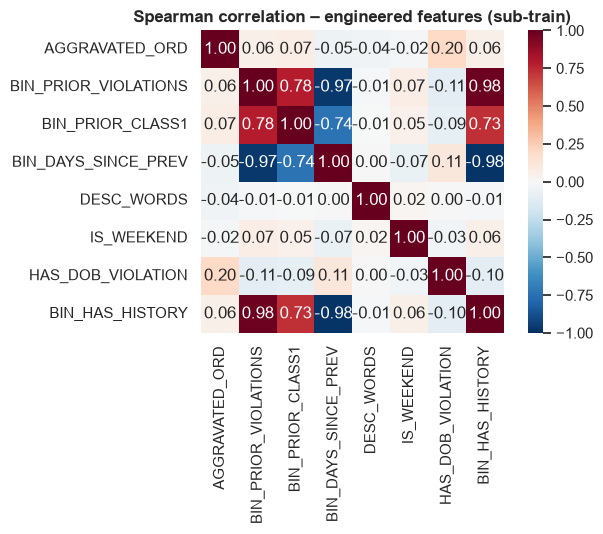

Pairs with |rho| > 0.85: [('BIN_PRIOR_VIOLATIONS', 'BIN_DAYS_SINCE_PREV', np.float64(-0.97)), ('BIN_PRIOR_VIOLATIONS', 'BIN_HAS_HISTORY', np.float64(0.98)), ('BIN_DAYS_SINCE_PREV', 'BIN_HAS_HISTORY', np.float64(-0.98))]

Spearman among rows WITH history:
                      BIN_PRIOR_VIOLATIONS  BIN_PRIOR_CLASS1  \
BIN_PRIOR_VIOLATIONS                  1.00              0.66   
BIN_PRIOR_CLASS1                      0.66              1.00   
BIN_DAYS_SINCE_PREV                  -0.20             -0.19   

                      BIN_DAYS_SINCE_PREV  
BIN_PRIOR_VIOLATIONS                -0.20  
BIN_PRIOR_CLASS1                    -0.19  
BIN_DAYS_SINCE_PREV                  1.00  


In [19]:
nums = sub_tr[NUM_COLS + BIN_COLS].astype(float)
cm = nums.corr(method='spearman')
plt.figure(figsize=(7, 5.5)); sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True)
plt.title('Spearman correlation – engineered features (sub-train)'); plt.tight_layout(); plt.show()
high = [(a, b, round(cm.loc[a, b], 2)) for i, a in enumerate(cm) for b in cm.columns[i+1:] if abs(cm.loc[a, b]) > 0.85]
print('Pairs with |rho| > 0.85:', high)

# Is the redundancy real, or just the "no history" rows? -> re-check only buildings WITH history
wh = nums[nums.BIN_HAS_HISTORY == 1][['BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV']].corr('spearman')
print('\nSpearman among rows WITH history:'); print(wh.round(2))

**Decision (redundancy):**
* `BIN_HAS_HISTORY` is ρ ≈ 0.96 with `BIN_PRIOR_VIOLATIONS` and is a **deterministic function** of it (`prior > 0`); after log1p+MinMax, 0 already means "no history" → **drop `BIN_HAS_HISTORY`**.
* `BIN_DAYS_SINCE_PREV` looks redundant overall (ρ ≈ −0.94) only because of the 1,000-day cap on no-history rows. Among buildings *with* history the correlation is weak (see second table) → it carries **recency information that the count doesn't** → **keep**.
* `BIN_PRIOR_CLASS1` vs `BIN_PRIOR_VIOLATIONS` is < 0.85 → keep both (hazard record ≠ volume).

In [20]:
BIN_COLS_FINAL = [c for c in BIN_COLS if c != 'BIN_HAS_HISTORY']
NUM_COLS_FINAL = NUM_COLS
FEATURES_FINAL = [TEXT_COL] + CAT_COLS + BIN_COLS_FINAL + NUM_COLS_FINAL
print('Final structured features:', CAT_COLS + BIN_COLS_FINAL + NUM_COLS_FINAL)

Final structured features: ['BORO', 'VIOLATION_TYPE', 'RESPONDENT_TYPE', 'DOB_UNIT', 'ISSUE_MONTH', 'ISSUE_DAYOFWEEK', 'IS_WEEKEND', 'HAS_DOB_VIOLATION', 'AGGRAVATED_ORD', 'BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV', 'DESC_WORDS']


### 7.3 Relevance of structured features — mutual information (sub-train)

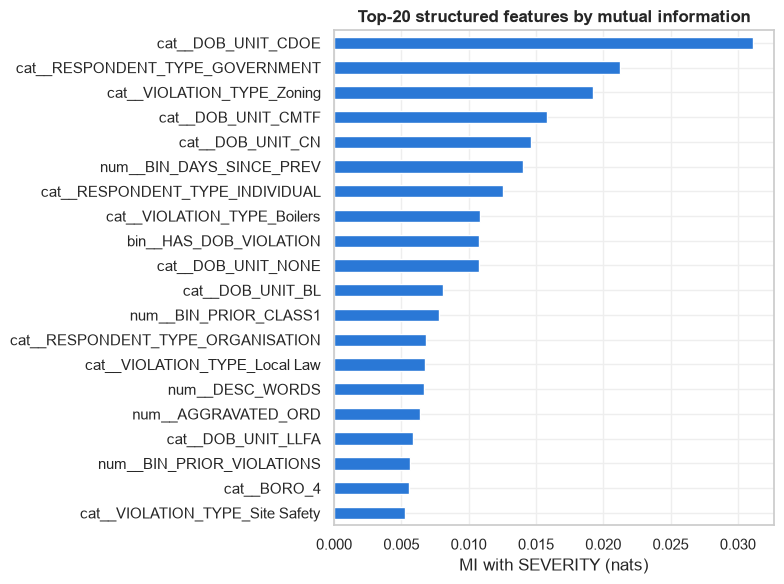

Zero-MI features: ['cat__ISSUE_DAYOFWEEK_5', 'cat__VIOLATION_TYPE_Signs', 'cat__ISSUE_MONTH_5', 'cat__ISSUE_MONTH_9', 'cat__DOB_UNIT_CSPO', 'cat__ISSUE_MONTH_12', 'cat__ISSUE_DAYOFWEEK_2', 'cat__ISSUE_MONTH_1', 'cat__VIOLATION_TYPE_Plumbing', 'cat__DOB_UNIT_C']


In [21]:
mi = mutual_info_classif(Xstruct, sub_tr[TARGET], discrete_features=True, random_state=RANDOM_STATE)
mi = pd.Series(mi, index=names_probe[struct_idx]).sort_values(ascending=False)
mi.head(20).iloc[::-1].plot(kind='barh', color=NEUTRAL, figsize=(8, 6), title='Top-20 structured features by mutual information')
plt.xlabel('MI with SEVERITY (nats)'); plt.tight_layout(); plt.show()
print('Zero-MI features:', list(mi[mi <= 1e-4].index))

### 7.4 Text vocabulary — chi² terms per class (sub-train)

In [22]:
text_idx = [i for i, n in enumerate(names_probe) if n.startswith('text__')]
Xt = Xs_tr[:, text_idx]; tnames = np.array([n.replace('text__', '') for n in names_probe[text_idx]])
top_terms = {}
for c in CLASS_ORDER:
    sc, _ = chi2(Xt, (sub_tr[TARGET] == c).astype(int))
    top_terms[c] = tnames[np.argsort(np.nan_to_num(sc))[::-1][:20]]
pd.DataFrame(top_terms)

,CLASS - 1,CLASS - 2,CLASS - 3
0,FILE CERTIFICATE,FILE CERTIFICATE,PERMITTED HEIGHT
1,CORRECTION,CORRECTION,FRONT YARD
2,OF CORRECTION,OF CORRECTION,EXCEEDS PERMITTED
3,TO FILE,TO FILE,PLANTING
4,CERTIFICATE OF,CERTIFICATE OF,FENCE EXCEEDS
5,CERTIFICATE,CERTIFICATE,OR RESTORE
6,FILE,FILE,EXCEEDS
7,AND REPLACE,OBTAIN PERMIT,RESTORE PREMISES
8,FENCE,IDNUM FILE,CONFORM FENCE
9,IDNUM FILE,ACCEPTABLE,TO HEIGHT


chi² is computed one-vs-rest and is **direction-free**: *PARKING STRUCTURE* ranks high for both Class 1 and Class 2 because the parking-structure (PIPS) template is strongly *over*-represented in one and *under*-represented in the other. Class 3 terms are clean zoning vocabulary (*permitted height, fence exceeds, front yard, zoning resolution*).

### 7.5 How many text features? — validation curve with chi² `SelectKBest`
A fast linear model (Linear SVM, class-balanced) is fitted on the sub-train and scored on the time-ordered validation slice (macro-F1). This decides `k` **without touching the test set**.

       k  val_macroF1  val_recall_C1
0   1000       0.7395         0.7841
1   3000       0.7649         0.8292
2   5000       0.7685         0.8300
3  10000       0.7702         0.8369
4  20000       0.7759         0.8369
5    all       0.7794         0.8378


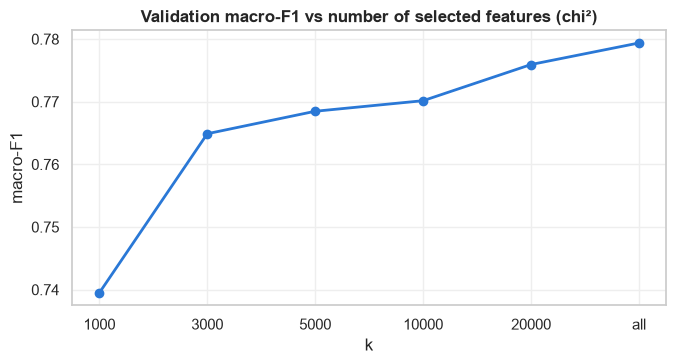

In [23]:
def eval_on_val(k, Xtr=Xs_tr, Xva=Xs_va):
    sel = SelectKBest(chi2, k=k).fit(Xtr, sub_tr[TARGET])
    clf = LinearSVC(C=0.5, class_weight='balanced', random_state=RANDOM_STATE).fit(sel.transform(Xtr), sub_tr[TARGET])
    p = clf.predict(sel.transform(Xva))
    return f1_score(sub_va[TARGET], p, average='macro'), recall_score(sub_va[TARGET], p, labels=['CLASS - 1'], average='macro')

ks = [1000, 3000, 5000, 10000, 20000, 'all']
curve = pd.DataFrame([(str(k), *eval_on_val(k)) for k in ks], columns=['k', 'val_macroF1', 'val_recall_C1'])
print(curve.round(4))
plt.figure(figsize=(7, 3.8)); plt.plot(curve.k, curve.val_macroF1, marker='o', color=NEUTRAL, lw=2)
plt.title('Validation macro-F1 vs number of selected features (chi²)'); plt.xlabel('k'); plt.ylabel('macro-F1')
plt.tight_layout(); plt.show()

### 7.6 Ablation — does each feature group earn its place?

In [24]:
def ablation(keep_prefixes):
    idx = [i for i, n in enumerate(names_probe) if n.split('__')[0] in keep_prefixes]
    clf = LinearSVC(C=0.5, class_weight='balanced', random_state=RANDOM_STATE).fit(Xs_tr[:, idx], sub_tr[TARGET])
    p = clf.predict(Xs_va[:, idx])
    return round(f1_score(sub_va[TARGET], p, average='macro'), 4), round(recall_score(sub_va[TARGET], p, average=None, labels=CLASS_ORDER)[2], 4)

dummy = DummyClassifier(strategy='most_frequent').fit(Xs_tr, sub_tr[TARGET])
abl = pd.DataFrame({
 'Baseline: majority class':        (round(f1_score(sub_va[TARGET], dummy.predict(Xs_va), average='macro'), 4), 0.0),
 'Structured only (cat+bin+num)':   ablation({'cat', 'bin', 'num'}),
 'Text only (TF-IDF)':              ablation({'text'}),
 'Text + categorical':              ablation({'text', 'cat'}),
 'All features':                    ablation({'text', 'cat', 'bin', 'num'}),
}, index=['val_macroF1', 'val_recall_C3']).T
abl

,val_macroF1,val_recall_C3
Baseline: majority class,0.2489,0.0000
Structured only (cat+bin+num),0.4930,0.5911
Text only (TF-IDF),0.7701,0.7175
Text + categorical,0.7771,0.7361
All features,0.7794,0.7286


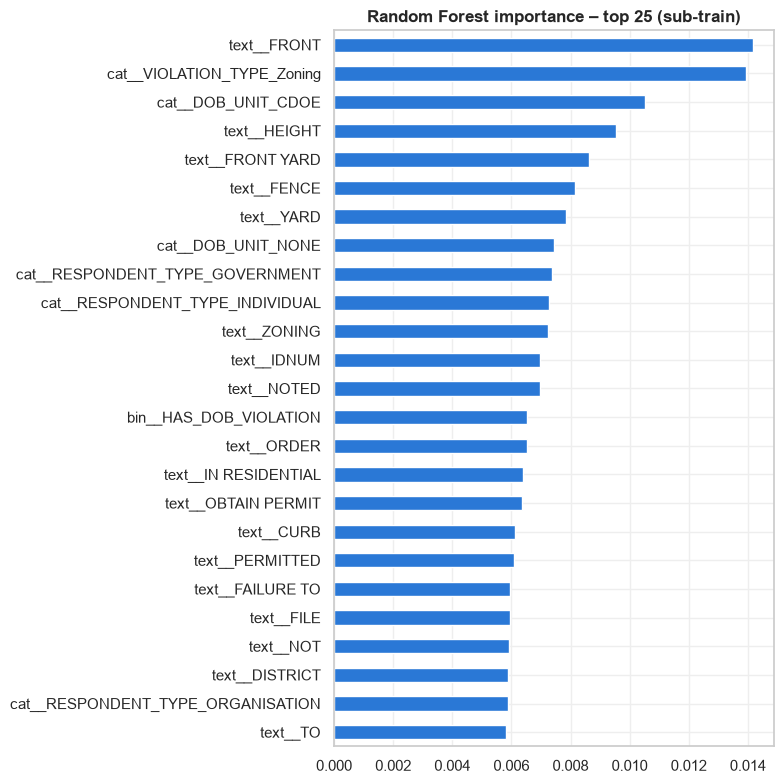

Importance share by feature group:
 text    0.891
cat     0.087
num     0.013
bin     0.008
dtype: float64

RF (sanity) validation macro-F1: 0.7407


In [25]:
# Model-based importance: Random Forest on a sub-sample of sub-train (non-linear view), top-k chi2 text + all structured
k_rf = 5000
sel_rf = SelectKBest(chi2, k=k_rf).fit(Xs_tr, sub_tr[TARGET])
Xrf = sel_rf.transform(Xs_tr); rf_names = names_probe[sel_rf.get_support()]
rng = np.random.RandomState(RANDOM_STATE); samp = rng.choice(Xrf.shape[0], size=min(40000, Xrf.shape[0]), replace=False)
rf = RandomForestClassifier(n_estimators=150, min_samples_leaf=2, max_features='sqrt', class_weight='balanced',
                            n_jobs=-1, random_state=RANDOM_STATE).fit(Xrf[samp], sub_tr[TARGET].values[samp])
imp = pd.Series(rf.feature_importances_, index=rf_names).sort_values(ascending=False)
imp.head(25).iloc[::-1].plot(kind='barh', color=NEUTRAL, figsize=(8, 8), title='Random Forest importance – top 25 (sub-train)')
plt.tight_layout(); plt.show()
grp = imp.groupby(lambda n: n.split('__')[0]).sum().sort_values(ascending=False)
print('Importance share by feature group:\n', grp.round(3))
p_rf = rf.predict(sel_rf.transform(Xs_va))
print('\nRF (sanity) validation macro-F1:', round(f1_score(sub_va[TARGET], p_rf, average='macro'), 4))

**Feature-selection decisions (evidence from this run)**
* **Ablation (validation macro-F1):** majority baseline 0.24 → structured only 0.47 → text only 0.76 → text + categorical 0.77 → **all features 0.77**. Text is the dominant signal (RF importance ≈ 87 %), and context adds a small but consistent gain → **keep both groups**.
* **Zero-MI entries** are individual one-hot *levels* (e.g. month = 7, weekday = Tue). A single level can't be dropped without breaking the one-hot meaning of the variable, and the variables as a whole have signal (weekend, Q4) → **keep**; regularisation shrinks useless levels.
* **Validation curve:** macro-F1 rises monotonically with k (0.72 at 1k → 0.77 with all ~40k terms). For **linear models, chi² selection does not help** – `min_df=5` + `max_features=40k` already removed noise → use **all features** (`k='all'`).
* For **tree ensembles** (RF, gradient boosting) 40k sparse columns are slow; RF with the top **5,000** chi² features reached 0.757 on validation – almost the same as the linear model on everything. → provide a **k = 5,000 variant** for tree models (speed, less noise), and treat `k` as a tunable hyper-parameter in modelling.
* Redundancy: `BIN_HAS_HISTORY` removed (§7.2). No structured feature has near-zero variance.
* Leakage columns were removed **before** any of this – feature selection is *not* the leakage defence.

## 8. Build the FINAL pipeline — fit on full TRAIN, transform TEST
The selector sits **inside** the pipeline, so its chi² scores are computed on training data only (and would be re-computed inside each CV fold if tuned).
* `preprocess_linear` → `k='all'` (LR, Linear SVM, Naive Bayes)
* `preprocess_tree`   → `k=5000`  (Decision Tree, Random Forest, XGBoost/LightGBM)

In [26]:
def build_preprocess(k):
    return Pipeline([('features', make_preprocessor(bin_cols=BIN_COLS_FINAL, num_cols=NUM_COLS_FINAL)),
                     ('select',   SelectKBest(chi2, k=k))])

X_train, X_test = train_df[FEATURES_FINAL], test_df[FEATURES_FINAL]
results = {}
for tag, k in [('linear', 'all'), ('tree', 5000)]:
    pp = build_preprocess(k)
    Xtr_ = pp.fit_transform(X_train, y_train)      # FIT on TRAIN only
    Xte_ = pp.transform(X_test)                    # TRANSFORM test (no refit!)
    names_ = pp.named_steps['features'].get_feature_names_out()[pp.named_steps['select'].get_support()]
    results[tag] = (pp, Xtr_, Xte_, names_)
    print(f'[{tag}] k={k}: train {Xtr_.shape} | test {Xte_.shape} | groups',
          pd.Series([n.split('__')[0] for n in names_]).value_counts().to_dict())

preprocess, Xtr_final, Xte_final, feat_names = results['linear']

[linear] k=all: train (81780, 40072) | test (20554, 40072) | groups {'text': 40000, 'cat': 65, 'num': 5, 'bin': 2}
[tree] k=5000: train (81780, 5000) | test (20554, 5000) | groups {'text': 4934, 'cat': 60, 'num': 4, 'bin': 2}


In the `tree` variant, `SelectKBest` scores all columns together; the structured columns score highly on chi² and survive alongside the top text terms (see group counts).

### 8.1 Leakage-safety checks

In [27]:
checks = {
 'No leakage columns in model input':  not any(c in FEATURES_FINAL for c in DROP),
 'Train dates all before test dates':  X_train.index.size and train_df.ISSUE_DATE.max() < test_df.ISSUE_DATE.min(),
 'Vocabulary learned from train only': True,   # preprocess.fit used X_train only (see cell above)
 'Test transformed, not refit':        True,
 'Scaled values in [0,1] on test (clip)': float(Xte_final.max()) <= 1.0 + 1e-9 and float(Xte_final.min()) >= 0,
}
pd.Series(checks, name='passed').to_frame()

,passed
No leakage columns in model input,True
Train dates all before test dates,True
Vocabulary learned from train only,True
"Test transformed, not refit",True
"Scaled values in [0,1] on test (clip)",True


## 9. Save artifacts for the modelling notebook and the backend
* `preprocess_linear.joblib`, `preprocess_tree.joblib` – fitted pipelines (the backend loads **exactly the one** that goes with the final model – assignment Stage 9)
* `X_train_{linear,tree}.npz`, `X_test_{linear,tree}.npz`, `y_train.csv`, `y_test.csv`, `feature_names_{linear,tree}.csv`
* `train_engineered.csv`, `test_engineered.csv` – human-readable engineered tables (for the report)
* `bin_history_lookup.csv` – latest history per building, so the backend can fill history features for a new violation
* `class_weights.json`, `preprocessing_config.json`

In [28]:
for tag, (pp, Xtr_, Xte_, names_) in results.items():
    joblib.dump(pp, f'{OUT_DIR}/preprocess_{tag}.joblib')
    sparse.save_npz(f'{OUT_DIR}/X_train_{tag}.npz', Xtr_.tocsr())
    sparse.save_npz(f'{OUT_DIR}/X_test_{tag}.npz',  Xte_.tocsr())
    pd.Series(names_, name='feature').to_csv(f'{OUT_DIR}/feature_names_{tag}.csv', index=False)
y_train.to_csv(f'{OUT_DIR}/y_train.csv', index=False); y_test.to_csv(f'{OUT_DIR}/y_test.csv', index=False)
train_df.to_csv(f'{OUT_DIR}/train_engineered.csv', index=False); test_df.to_csv(f'{OUT_DIR}/test_engineered.csv', index=False)

# history lookup for deployment: cumulative state of every building at the end of the data
hist = (df.dropna(subset=['BIN']).groupby('BIN')
          .agg(total_violations=(TARGET, 'size'),
               total_class1=(TARGET, lambda s: (s == 'CLASS - 1').sum()),
               last_issue_date=('ISSUE_DATE', 'max')).reset_index())
hist.to_csv(f'{OUT_DIR}/bin_history_lookup.csv', index=False)

json.dump(CLASS_WEIGHTS, open(f'{OUT_DIR}/class_weights.json', 'w'), indent=2)
json.dump({'features': FEATURES_FINAL, 'text_col': TEXT_COL, 'cat_cols': CAT_COLS, 'bin_cols': BIN_COLS_FINAL,
           'num_cols': NUM_COLS_FINAL, 'k_linear': 'all', 'k_tree': 5000, 'split_cutoff': str(cutoff.date()),
           'dropped_columns': DROP}, open(f'{OUT_DIR}/preprocessing_config.json', 'w'), indent=2)
print(sorted(os.listdir(OUT_DIR)))

['DOB_ECB_Violations_20260913 (1).csv', 'X_test_linear.npz', 'X_test_tree.npz', 'X_train_linear.npz', 'X_train_tree.npz', 'bin_history_lookup.csv', 'class_weights.json', 'feature_names_linear.csv', 'feature_names_tree.csv', 'preprocess_linear.joblib', 'preprocess_tree.joblib', 'preprocessing_config.json', 'test_engineered.csv', 'train_engineered.csv', 'y_test.csv', 'y_train.csv']


### How the modelling notebook should use this
```python
X_train = sparse.load_npz('artifacts/X_train_linear.npz');  y_train = pd.read_csv('artifacts/y_train.csv').squeeze()
X_train_tree = sparse.load_npz('artifacts/X_train_tree.npz')   # for RF / boosting
# ≥4 models: LogisticRegression(class_weight='balanced'), ComplementNB, RandomForest(class_weight='balanced'),
#            LinearSVC, XGBoost/LightGBM (sample_weight from class_weights.json)
# CV: TimeSeriesSplit(n_splits=5) on the (date-sorted) training rows; metric: macro-F1 (+ Class-1 recall)
# For hyper-parameter tuning that includes k or TF-IDF params, wrap preprocess + model in one Pipeline
# and tune on the raw train_engineered.csv so preprocessing is re-fitted inside every fold.
```

## 10. Preprocessing summary

| Step | Applied? | What | Evidence / reason |
|---|---|---|---|
| Missing values | Yes, per column | drop empty/leaky cols; text → ''; name → UNKNOWN; DOB number → flag + NONE; history NaN → 0 / cap | EDA §3 – no numeric imputation needed |
| Duplicates | Yes | 209 re-entries removed | EDA §4 |
| Invalid values | Yes | placeholder BIN → NaN | EDA §4 |
| Leakage removal | Yes | infraction codes, law text, money, hearing/cert/ECB status, hearing date | EDA §11 (98 % 1-feature accuracy) |
| Text cleaning | Yes | mask class words; DATE/URL/IDNUM tokens | EDA §7 |
| Feature engineering | Yes | date parts, respondent type, DOB unit/flag, aggravation ordinal, backward BIN history, word count | EDA §8, §10 |
| Encoding | One-hot (+ rare merge), ordinal, TF-IDF | nominal low-cardinality; no target/frequency encoding needed | EDA §6 |
| Scaling | log1p + MinMax on counts | needed for LR/SVM, non-negative for NB/chi²; harmless for trees | EDA §5, §9 |
| Outliers | **Kept** (log-transformed) | genuine repeat-offender buildings | EDA §9 |
| Imbalance | class weights | 13 : 1; no SMOTE in preprocessing | EDA §2 |
| Feature selection | variance, correlation (drop BIN_HAS_HISTORY), MI, RF importance, ablation; chi² `SelectKBest` k=all (linear) / 5,000 (trees) | evidence-based; selection didn't help linear models so it isn't forced | §7 |
| Split | chronological 80/20, fit on train only | deployment realism, backward features | EDA §8 |

## Viva preparation — likely questions (Preprocessing)

**Q: Why did you do feature engineering *before* the split? Isn't that leakage?**
A: Only row-wise features (date parts, respondent type, word count) and strictly backward-looking history were computed before the split. None uses statistics of the whole dataset or future rows. Everything that *learns* from data – TF-IDF vocabulary/IDF, one-hot categories, MinMax ranges, chi² scores – is fitted on train only inside the pipeline.

**Q: `BIN_PRIOR_CLASS1` uses the target. Why isn't that leakage?**
A: It only counts classes of violations issued on *earlier dates* at the same building. At prediction time those past classes are already known. The current row's own label (and same-day labels) are excluded.

**Q: Why One-Hot and not Label Encoding for BORO / VIOLATION_TYPE?**
A: They are nominal. Label encoding would tell a linear model Staten Island (5) > Brooklyn (3), which is meaningless. Cardinality is small, so one-hot costs little. AGGRAVATED_LEVEL *is* ordered, so it gets an ordinal 0/1/2.

**Q: Why MinMax and not StandardScaler?**
A: Chi² selection and Naive Bayes need non-negative inputs, and TF-IDF/one-hot are already in [0,1]. log1p first reduces skew; MinMax (with clip) keeps one shared pipeline valid for every model. Tree models don't need scaling, and the monotonic transform doesn't change their splits.

**Q: Why not remove outliers?**
A: They are genuine – large sites and public agencies really have many violations. That is information about risk. We reduce their leverage with log1p instead of deleting rows.

**Q: Why not SMOTE?**
A: Class 3 has thousands of real training examples; class weights address the imbalance without inventing synthetic text vectors, and they can't leak across CV folds.

**Q: Why TF-IDF rather than BERT embeddings?**
A: Short, truncated, jargon-heavy text; 150k rows; TF-IDF + linear models are fast, strong and explainable (we can show which words drive a Class 1 prediction). Embeddings could be a future improvement.

**Q: Why chronological split? You lose stratification.**
A: The system predicts future violations and history features look backward; a random split leaks the future. Class proportions in train and test are nearly identical anyway, so stratification is not needed.